In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [2]:
cancer = load_breast_cancer()
cancer.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [3]:
df=pd.DataFrame(np.c_[cancer['data'],cancer['target']], columns=np.append(cancer['feature_names'],['target']))
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [4]:
df.isna().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [5]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1].values

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [8]:
from sklearn.neighbors import KNeighborsClassifier
classifier=KNeighborsClassifier(n_neighbors=25,metric='minkowski')
classifier.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=25)

In [9]:
y_pred=classifier.predict(X_test)
y_pred

array([0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0.,
       1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0.,
       0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
       1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1.])

In [10]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
print("confusion matrix")
print(cm)
print("accuracy score")
print(acc)

confusion matrix
[[42  5]
 [ 0 67]]
accuracy score
0.956140350877193


<Axes: >

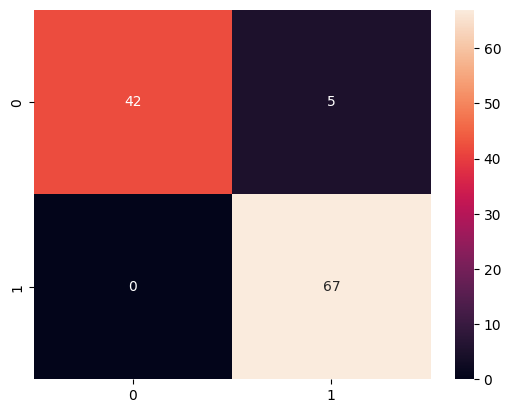

In [11]:
from seaborn import heatmap
sns.heatmap(cm,annot=True)

In [33]:
df=pd.read_csv('/content/drive/MyDrive/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [13]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [14]:
df['person_emp_length'].fillna(df['person_emp_length'].mean(),inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].mean(),inplace=True)


/tmp/ipython-input-476307843.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].mean(),inplace=True)
/tmp/ipython-input-476307843.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(valu

<Axes: ylabel='person_income'>

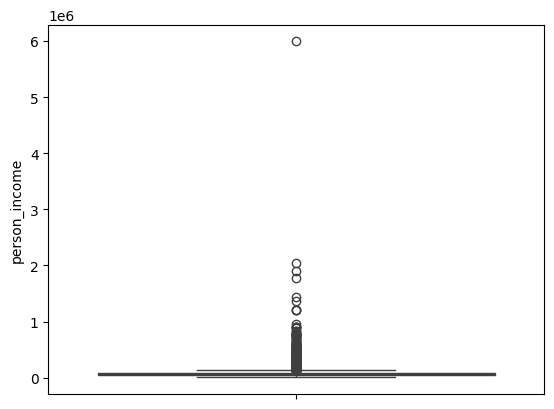

In [15]:
#check outliers
sns.boxplot(df['person_income'])


In [16]:
IQR=df['person_income'].quantile(0.75)-df['person_income'].quantile(0.25)
lower_limit=df['person_income'].quantile(0.25)-(IQR*1.5)
upper_limit=df['person_income'].quantile(0.75)+(IQR*1.5)

df.loc[df['person_income']<lower_limit, 'person_income'] = lower_limit
df.loc[df['person_income']>upper_limit, 'person_income'] = upper_limit

<Axes: ylabel='person_income'>

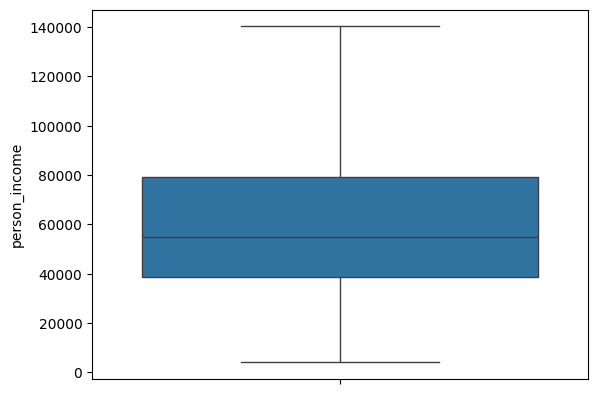

In [17]:
sns.boxplot(df['person_income'])


<Axes: ylabel='loan_amnt'>

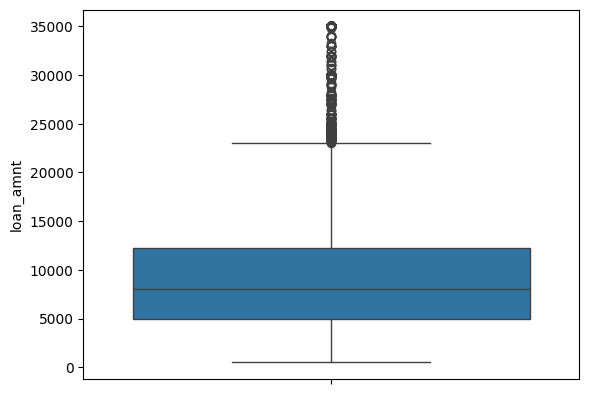

In [18]:
sns.boxplot(df['loan_amnt'])

In [19]:
IQR=df['loan_amnt'].quantile(0.75)-df['loan_amnt'].quantile(0.25)
lower_limit=df['loan_amnt'].quantile(0.25)-(IQR*1.5)
upper_limit=df['loan_amnt'].quantile(0.75)+(IQR*1.5)
df.loc[df['loan_amnt']<lower_limit, 'loan_amnt'] = lower_limit
df.loc[df['loan_amnt']>upper_limit, 'loan_amnt'] = upper_limit

In [20]:
df = df.drop(columns=[
    'person_home_ownership',
    'loan_intent',
    'cb_person_default_on_file'
])


In [21]:
df

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,D,23000,16.02,1,0.59,3
1,21,9600,5.0,B,1000,11.14,0,0.10,2
2,25,9600,1.0,C,5500,12.87,1,0.57,3
3,23,65500,4.0,C,23000,15.23,1,0.53,2
4,24,54400,8.0,C,23000,14.27,1,0.55,4
...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,C,5800,13.16,0,0.11,30
32577,54,120000,4.0,A,17625,7.49,0,0.15,19
32578,65,76000,3.0,B,23000,10.99,1,0.46,28
32579,56,140250,5.0,B,15000,11.48,0,0.10,26


In [22]:
df = df.loc[:, df.nunique() > 1]
df

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,D,23000,16.02,1,0.59,3
1,21,9600,5.0,B,1000,11.14,0,0.10,2
2,25,9600,1.0,C,5500,12.87,1,0.57,3
3,23,65500,4.0,C,23000,15.23,1,0.53,2
4,24,54400,8.0,C,23000,14.27,1,0.55,4
...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,C,5800,13.16,0,0.11,30
32577,54,120000,4.0,A,17625,7.49,0,0.15,19
32578,65,76000,3.0,B,23000,10.99,1,0.46,28
32579,56,140250,5.0,B,15000,11.48,0,0.10,26


In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['loan_status'] = le.fit_transform(df['loan_status'])
df['loan_grade'] = le.fit_transform(df['loan_grade'])
df

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,3,23000,16.02,1,0.59,3
1,21,9600,5.0,1,1000,11.14,0,0.10,2
2,25,9600,1.0,2,5500,12.87,1,0.57,3
3,23,65500,4.0,2,23000,15.23,1,0.53,2
4,24,54400,8.0,2,23000,14.27,1,0.55,4
...,...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,2,5800,13.16,0,0.11,30
32577,54,120000,4.0,0,17625,7.49,0,0.15,19
32578,65,76000,3.0,1,23000,10.99,1,0.46,28
32579,56,140250,5.0,1,15000,11.48,0,0.10,26


In [24]:
X=df.drop(columns=['loan_status'])
y=df['loan_status']

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [26]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [27]:
from sklearn.neighbors import KNeighborsClassifier
classifier=KNeighborsClassifier(n_neighbors=25,metric='minkowski')
classifier.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=25)

In [28]:
y_pred=classifier.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [29]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
print("confusion matrix")
print(cm)
print("accuracy score")
print(acc)

confusion matrix
[[4872  307]
 [ 636  702]]
accuracy score
0.8553015191038822
